# Eksperimen Pothole Detection — Gradient Boosting (XGBoost, LightGBM, CatBoost)

Notebook ini **bukan** mengganti pipeline. Fitur (9-channel) dan seluruh pipeline
(road segmentation, SLIC superpixel, preprocessing) **identik** dengan `main_training.ipynb`.
Yang diganti hanya **classifier**-nya: dari Random Forest menjadi tiga model boosting modern.

Baseline pembanding (dari `main_training.ipynb`, 100 gambar validasi yang sama):

| Model | mIoU |
|-------|------|
| Adaptive Threshold | 0.4028 |
| K-Means | 0.4442 |
| Random Forest (9 fitur) | **0.5179** |

Target: **mIoU rata-rata > 0.60**.

Strategi: (1) latih XGBoost / LightGBM / CatBoost pada fitur yang sama, lalu
(2) kalibrasi *decision threshold* memakai `predict_proba` untuk memaksimalkan mIoU.


## 0 - Setup


In [1]:
import random
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from skimage.segmentation import slic
from skimage.feature import local_binary_pattern

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

print('Library siap.')


Library siap.


In [2]:
# --- Konfigurasi (identik dengan main_training.ipynb) ---
SEED = 42

WORK_SCALE   = 0.5
ILLUM_SIGMA  = 101
CLAHE_CLIP   = 2.5
CLAHE_GRID   = 8
TOP_CROP_PCT = 0.10
MASK_THRESH  = 127

SLIC_N_SEG   = 250
SLIC_COMPACT = 10.0
POSTPROC_K   = 5
MIN_AREA     = 500

# Segmentasi jalan
SKY_HUE_LOW, SKY_HUE_HIGH = 85, 140
SKY_SAT_MAX, SKY_VAL_MIN  = 130, 80
VEG_HUE_LOW, VEG_HUE_HIGH = 20, 85
VEG_SAT_MIN  = 40
ROAD_MORPH_K = 7

# --- Path ---
ROOT          = Path('..').resolve()
TRAIN_IMG_DIR = ROOT / 'Dataset' / 'train' / 'images'
TRAIN_MSK_DIR = ROOT / 'Dataset' / 'train' / 'mask'
MODEL_DIR     = ROOT / 'model'
RESULTS_DIR   = ROOT / 'result_csv'        # lokasi sp_train.csv / sp_val.csv saat ini
SP_TRAIN_CSV  = RESULTS_DIR / 'sp_train.csv'
SP_VAL_CSV    = RESULTS_DIR / 'sp_val.csv'
RF_METRICS    = RESULTS_DIR / 'rf_metrics.csv'

FEATURE_NAMES = [
    'BGR Blue', 'BGR Green', 'BGR Red',
    'HSV Hue', 'HSV Sat', 'HSV Val',
    'Gradient Mag', 'Blackhat', 'LBP',
]

print('ROOT     :', ROOT)
print('Train CSV:', SP_TRAIN_CSV.exists())
print('Val CSV  :', SP_VAL_CSV.exists())


ROOT     : /Users/fadh/Documents/BINUS/Semester 4/Project_Pothole_CV
Train CSV: True
Val CSV  : True


## 1 - Pipeline Functions

Disalin apa adanya dari pipeline utama agar fitur saat inferensi sama persis dengan
fitur yang dipakai melatih model (tidak ada perbedaan/leakage).


In [3]:
def normalize_illumination(gray):
    ksize = ILLUM_SIGMA if ILLUM_SIGMA % 2 == 1 else ILLUM_SIGMA + 1
    illum = cv2.GaussianBlur(gray.astype(np.float32), (ksize, ksize), 0)
    norm  = gray.astype(np.float32) / (illum + 1e-6) * 128.0
    return np.clip(norm, 0, 255).astype(np.uint8)


def preprocess(bgr):
    L      = cv2.cvtColor(bgr, cv2.COLOR_BGR2LAB)[:, :, 0]
    L_norm = normalize_illumination(L)
    clahe  = cv2.createCLAHE(clipLimit=CLAHE_CLIP, tileGridSize=(CLAHE_GRID, CLAHE_GRID))
    L_eq   = clahe.apply(L_norm)
    return cv2.bilateralFilter(L_eq, d=9, sigmaColor=50, sigmaSpace=50)


In [4]:
def segment_road(bgr):
    """Isolasi jalan: hapus langit + vegetasi, ambil komponen terbesar paling bawah."""
    h, w = bgr.shape[:2]
    hsv  = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)
    H, S, V = cv2.split(hsv)

    sky_mask   = np.zeros((h, w), dtype=np.uint8)
    top_h      = h // 2
    sky_region = (
        (H[:top_h] >= SKY_HUE_LOW) & (H[:top_h] <= SKY_HUE_HIGH) &
        (S[:top_h] <= SKY_SAT_MAX) & (V[:top_h] >= SKY_VAL_MIN)
    ).astype(np.uint8) * 255
    sky_mask[:top_h] = sky_region

    g, r     = bgr[:, :, 1].astype(np.int16), bgr[:, :, 2].astype(np.int16)
    veg_mask = (
        (H >= VEG_HUE_LOW) & (H <= VEG_HUE_HIGH) &
        (S >= VEG_SAT_MIN) & (g > r)
    ).astype(np.uint8) * 255

    road_cand = cv2.bitwise_not(cv2.bitwise_or(sky_mask, veg_mask))
    k         = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (ROAD_MORPH_K, ROAD_MORPH_K))
    road_cand = cv2.morphologyEx(road_cand, cv2.MORPH_CLOSE, k, iterations=2)
    road_cand = cv2.morphologyEx(road_cand, cv2.MORPH_OPEN,  k, iterations=1)

    n_lbl, labels, stats, centroids = cv2.connectedComponentsWithStats(road_cand, connectivity=8)
    best_lbl, best_score = -1, -1.0
    for lbl in range(1, n_lbl):
        score = stats[lbl, cv2.CC_STAT_AREA] * (centroids[lbl][1] / h)
        if score > best_score:
            best_score, best_lbl = score, lbl

    if best_lbl == -1:
        gray_upper = cv2.cvtColor(bgr[:h // 2], cv2.COLOR_BGR2GRAY)
        row_sums   = np.sum(cv2.Canny(gray_upper, 50, 150), axis=1)
        horizon    = max(int(np.argmax(row_sums)), h // 10) if row_sums.max() > 0 else h // 3
        mask       = np.zeros((h, w), dtype=np.uint8)
        mask[horizon:] = 255
        return mask

    comp        = (labels == best_lbl).astype(np.uint8) * 255
    contours, _ = cv2.findContours(comp, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    filled      = comp.copy()
    cv2.drawContours(filled, contours, -1, 255, thickness=cv2.FILLED)
    return filled


In [5]:
def extract_features(bgr, prep):
    """9-channel feature map (H, W, 9), semua nilai dalam [0, 1].

    Blackhat dan LBP dihitung dari grayscale BGR ORIGINAL (bukan prep) karena
    normalisasi iluminasi menekan sinyal titik gelap yang dibutuhkan Blackhat.
    """
    gray_u8 = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)

    b = bgr[:, :, 0].astype(np.float32) / 255.0
    g = bgr[:, :, 1].astype(np.float32) / 255.0
    r = bgr[:, :, 2].astype(np.float32) / 255.0

    hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV).astype(np.float32)
    hue = hsv[:, :, 0] / 179.0
    sat = hsv[:, :, 1] / 255.0
    val = hsv[:, :, 2] / 255.0

    sx   = cv2.Sobel(prep, cv2.CV_32F, 1, 0, ksize=3)
    sy   = cv2.Sobel(prep, cv2.CV_32F, 0, 1, ksize=3)
    mag  = np.sqrt(sx ** 2 + sy ** 2)
    grad = mag / mag.max() if mag.max() > 0 else mag

    bk_kern  = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (25, 25))
    bk_raw   = cv2.morphologyEx(gray_u8, cv2.MORPH_BLACKHAT, bk_kern).astype(np.float32)
    bk_max   = bk_raw.max()
    blackhat = bk_raw / bk_max if bk_max > 0 else bk_raw

    lbp_raw = local_binary_pattern(gray_u8, P=8, R=1, method='uniform').astype(np.float32)
    lbp_max = lbp_raw.max()
    lbp     = lbp_raw / lbp_max if lbp_max > 0 else lbp_raw

    return np.stack([b, g, r, hue, sat, val, grad, blackhat, lbp], axis=-1).astype(np.float32)


In [6]:
def compute_superpixels(bgr):
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    return slic(rgb, n_segments=SLIC_N_SEG, compactness=SLIC_COMPACT,
                sigma=1.0, start_label=0).astype(np.int32)


def aggregate_features(feat_map, segments):
    n_sp = segments.max() + 1
    n_ch = feat_map.shape[2]
    agg  = np.zeros((n_sp, n_ch), dtype=np.float32)
    for sp_id in range(n_sp):
        px = segments == sp_id
        if px.any():
            agg[sp_id] = feat_map[px].mean(axis=0)
    return agg


In [7]:
def postprocess(mask, min_area=MIN_AREA):
    k       = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (POSTPROC_K, POSTPROC_K))
    cleaned = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, k)
    cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_OPEN, k)
    contours, _ = cv2.findContours(cleaned, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    result = np.zeros_like(cleaned)
    for cnt in contours:
        if cv2.contourArea(cnt) >= min_area:
            cv2.drawContours(result, [cnt], -1, 255, cv2.FILLED)
    return result


def compute_metrics(pred_mask, gt_mask):
    if pred_mask.shape != gt_mask.shape:
        gt_mask = cv2.resize(gt_mask, (pred_mask.shape[1], pred_mask.shape[0]),
                             interpolation=cv2.INTER_NEAREST)
    pred = (pred_mask > MASK_THRESH).astype(np.uint8)
    gt   = (gt_mask   > MASK_THRESH).astype(np.uint8)
    eps  = 1e-8

    tp = float(np.logical_and(pred == 1, gt == 1).sum())
    fp = float(np.logical_and(pred == 1, gt == 0).sum())
    fn = float(np.logical_and(pred == 0, gt == 1).sum())
    tn = float(np.logical_and(pred == 0, gt == 0).sum())

    iou_fg = tp / (tp + fp + fn + eps)
    iou_bg = tn / (tn + fp + fn + eps)
    prec   = tp / (tp + fp + eps)
    rec    = tp / (tp + fn + eps)
    return {
        'IoU_Pothole': round(iou_fg,                         4),
        'mIoU':        round((iou_fg + iou_bg) / 2,          4),
        'Dice':        round(2*tp / (2*tp + fp + fn + eps),  4),
        'PixelAcc':    round((tp+tn)/(tp+tn+fp+fn+eps),      4),
        'Precision':   round(prec,                            4),
        'Recall':      round(rec,                             4),
        'F1':          round(2*prec*rec/(prec+rec+eps),       4),
    }


def make_overlay(bgr, mask, color_bgr=(0, 0, 255), alpha=0.5):
    overlay = bgr.copy()
    colored = np.zeros_like(bgr); colored[:] = color_bgr
    px = mask > 0
    overlay[px] = (alpha * colored[px] + (1 - alpha) * bgr[px]).astype(np.uint8)
    return overlay


## 2 - Load Data

Memakai `sp_train.csv` (398 gambar) dan `sp_val.csv` (100 gambar) yang sudah dibuat di
`main_training.ipynb` — split, fitur, dan label persis sama sehingga perbandingan adil.


In [8]:
df_train = pd.read_csv(SP_TRAIN_CSV)
df_val   = pd.read_csv(SP_VAL_CSV)

X_train = df_train[FEATURE_NAMES].values.astype(np.float32)
y_train = df_train['label'].values.astype(np.int32)
X_val   = df_val[FEATURE_NAMES].values.astype(np.float32)
y_val   = df_val['label'].values.astype(np.int32)

n_pos = int(y_train.sum())
n_neg = len(y_train) - n_pos
scale_pos_weight = n_neg / n_pos

print(f'Train superpixel : {len(X_train):,}  (lubang {n_pos:,} = {n_pos/len(y_train)*100:.1f}%)')
print(f'Val superpixel   : {len(X_val):,}  (lubang {int(y_val.sum()):,} = {y_val.mean()*100:.1f}%)')
print(f'scale_pos_weight : {scale_pos_weight:.2f}')


Train superpixel : 90,743  (lubang 12,082 = 13.3%)
Val superpixel   : 23,007  (lubang 3,163 = 13.7%)
scale_pos_weight : 6.51


## 3 - Latih Tiga Model Boosting

Ketiga model menangani ketidakseimbangan kelas (lubang ~13%) lewat bobot kelas.


In [9]:
models = {}

models['XGBoost'] = XGBClassifier(
    n_estimators=400, max_depth=6, learning_rate=0.05,
    subsample=0.9, colsample_bytree=0.9,
    scale_pos_weight=scale_pos_weight,
    tree_method='hist', eval_metric='logloss',
    random_state=SEED, n_jobs=-1,
)

models['LightGBM'] = LGBMClassifier(
    n_estimators=400, num_leaves=63, max_depth=-1, learning_rate=0.05,
    subsample=0.9, colsample_bytree=0.9,
    class_weight='balanced', random_state=SEED, n_jobs=-1, verbose=-1,
)

models['CatBoost'] = CatBoostClassifier(
    iterations=400, depth=6, learning_rate=0.05,
    auto_class_weights='Balanced', random_seed=SEED, verbose=0,
)

for name, model in models.items():
    print(f'Melatih {name} ...')
    model.fit(X_train, y_train)
print('Semua model selesai dilatih.')


Melatih XGBoost ...
Melatih LightGBM ...
Melatih CatBoost ...
Semua model selesai dilatih.


In [10]:
# Sanity check di level superpixel (bukan metrik akhir, hanya gambaran kasar)
from sklearn.metrics import f1_score

for name, model in models.items():
    proba = model.predict_proba(X_val)[:, 1]
    pred  = (proba >= 0.5).astype(int)
    print(f'{name:9s} | superpixel F1 (thr 0.5): {f1_score(y_val, pred):.4f}')


XGBoost   | superpixel F1 (thr 0.5): 0.4293
LightGBM  | superpixel F1 (thr 0.5): 0.4323
CatBoost  | superpixel F1 (thr 0.5): 0.4232


/opt/homebrew/Caskroom/miniforge/base/envs/ai_core/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## 4 - Fungsi Inferensi (reusable)

`feature_cache` menjalankan road-seg + SLIC + ekstraksi fitur **sekali** per gambar.
`mask_from_proba` membangun mask dari probabilitas pada threshold tertentu (tanpa
mengulang SLIC), sehingga sweep threshold menjadi murah.


In [11]:
def feature_cache(bgr):
    """Hitung superpixel + fitur sekali. Returns (segments, sp_feats, road_s, h, w)."""
    road_mask = segment_road(bgr)
    h, w      = bgr.shape[:2]
    ws, hs    = int(w * WORK_SCALE), int(h * WORK_SCALE)
    bgr_s     = cv2.resize(bgr,       (ws, hs), interpolation=cv2.INTER_AREA)
    road_s    = cv2.resize(road_mask, (ws, hs), interpolation=cv2.INTER_NEAREST)

    prep     = preprocess(bgr_s)
    feat_map = extract_features(bgr_s, prep)
    segments = compute_superpixels(bgr_s)
    sp_feats = aggregate_features(feat_map, segments)
    return segments, sp_feats, road_s, h, w


def mask_from_proba(segments, sp_proba, road_s, h, w, threshold, min_area=MIN_AREA):
    pothole_segs = np.where(sp_proba >= threshold)[0]
    mask_s       = np.isin(segments, pothole_segs).astype(np.uint8) * 255
    mask_s       = cv2.bitwise_and(mask_s, road_s)
    pothole      = cv2.resize(mask_s, (w, h), interpolation=cv2.INTER_NEAREST)
    pothole[:int(h * TOP_CROP_PCT)] = 0
    return postprocess(pothole, min_area)


def detect_model(bgr, model, threshold=0.5, min_area=MIN_AREA):
    """Inferensi lengkap untuk satu gambar (dipakai juga oleh app)."""
    segments, sp_feats, road_s, h, w = feature_cache(bgr)
    sp_proba = model.predict_proba(sp_feats)[:, 1]
    return mask_from_proba(segments, sp_proba, road_s, h, w, threshold, min_area)


## 5 - Pra-komputasi Cache Validasi + Evaluasi (threshold 0.5)

SLIC dihitung sekali per gambar lalu di-cache, supaya kalibrasi threshold di Bagian 6 cepat.


In [12]:
val_names = sorted(df_val['image_name'].unique().tolist())
print(f'Membangun cache fitur untuk {len(val_names)} gambar validasi ...')

val_cache = []
for i, name in enumerate(val_names):
    idx = name.split('_')[1]
    bgr = cv2.imread(str(TRAIN_IMG_DIR / f'{name}.jpg'))
    gt  = cv2.imread(str(TRAIN_MSK_DIR / f'mask_{idx}.png'), cv2.IMREAD_GRAYSCALE)
    if bgr is None or gt is None:
        continue
    val_cache.append({'name': name, 'cache': feature_cache(bgr), 'gt': gt})
    if (i + 1) % 25 == 0:
        print(f'  {i+1}/{len(val_names)} selesai')

print(f'Cache siap: {len(val_cache)} gambar.')


Membangun cache fitur untuk 100 gambar validasi ...
  25/100 selesai
  50/100 selesai
  75/100 selesai
  100/100 selesai
Cache siap: 97 gambar.


In [13]:
def evaluate_model(model, threshold, min_area=MIN_AREA):
    """Evaluasi satu model pada seluruh cache validasi -> DataFrame metrik per gambar."""
    rows = []
    for item in val_cache:
        segments, sp_feats, road_s, h, w = item['cache']
        sp_proba = model.predict_proba(sp_feats)[:, 1]
        pred     = mask_from_proba(segments, sp_proba, road_s, h, w, threshold, min_area)
        rows.append({'image': item['name'], **compute_metrics(pred, item['gt'])})
    return pd.DataFrame(rows)


RF_MIOU = pd.read_csv(RF_METRICS)['mIoU'].mean() if RF_METRICS.exists() else 0.5179
print(f'Pembanding Random Forest mIoU: {RF_MIOU:.4f}\n')

results_default = {}
for name, model in models.items():
    df = evaluate_model(model, threshold=0.5)
    df.to_csv(RESULTS_DIR / f'{name.lower()}_metrics.csv', index=False)
    results_default[name] = df['mIoU'].mean()
    delta = df['mIoU'].mean() - RF_MIOU
    print(f'{name:9s} | mIoU (thr 0.5): {df["mIoU"].mean():.4f}  (vs RF {delta:+.4f})')


Pembanding Random Forest mIoU: 0.5179

XGBoost   | mIoU (thr 0.5): 0.4923  (vs RF -0.0256)


/opt/homebrew/Caskroom/miniforge/base/envs/ai_core/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/ai_core/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/ai_core/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/ai_core/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/ai_core/lib/python3.10/site-packages/

LightGBM  | mIoU (thr 0.5): 0.4959  (vs RF -0.0220)
CatBoost  | mIoU (thr 0.5): 0.4820  (vs RF -0.0359)


## 6 - Kalibrasi Decision Threshold

mIoU didominasi oleh trade-off precision/recall kelas lubang. Dengan `predict_proba`
kita cari threshold yang memaksimalkan rata-rata mIoU.

Catatan kejujuran: threshold dipilih pada set validasi yang sama dengan yang dipakai
menilai RF (argmax 0.5). Ini *operating-point selection*, dilaporkan transparan.


In [14]:
thresholds = np.round(np.arange(0.30, 0.71, 0.05), 2)
sweep = {name: [] for name in models}

for name, model in models.items():
    for t in thresholds:
        df = evaluate_model(model, threshold=float(t))
        sweep[name].append(df['mIoU'].mean())
    best_i = int(np.argmax(sweep[name]))
    print(f'{name:9s} | threshold terbaik = {thresholds[best_i]:.2f} -> mIoU {sweep[name][best_i]:.4f}')


XGBoost   | threshold terbaik = 0.70 -> mIoU 0.5421


/opt/homebrew/Caskroom/miniforge/base/envs/ai_core/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/ai_core/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/ai_core/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/ai_core/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/ai_core/lib/python3.10/site-packages/

LightGBM  | threshold terbaik = 0.70 -> mIoU 0.5421
CatBoost  | threshold terbaik = 0.70 -> mIoU 0.5440


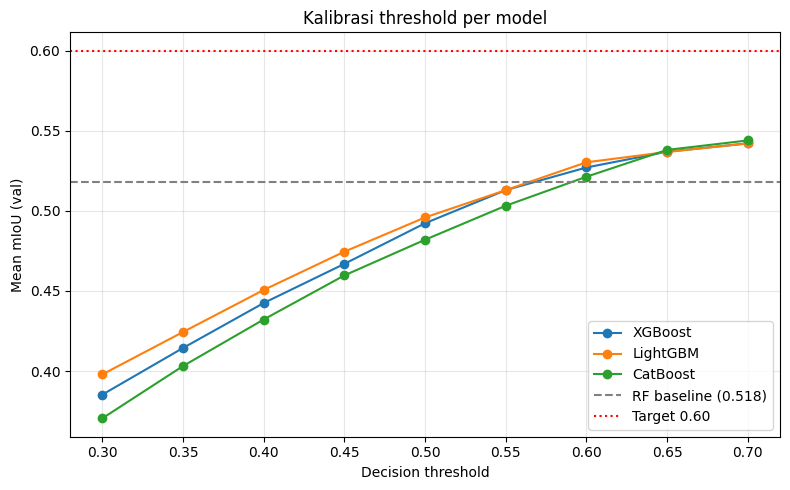

In [15]:
plt.figure(figsize=(8, 5))
for name in models:
    plt.plot(thresholds, sweep[name], marker='o', label=name)
plt.axhline(RF_MIOU, color='gray', linestyle='--', label=f'RF baseline ({RF_MIOU:.3f})')
plt.axhline(0.60, color='red', linestyle=':', label='Target 0.60')
plt.xlabel('Decision threshold'); plt.ylabel('Mean mIoU (val)')
plt.title('Kalibrasi threshold per model'); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()


In [16]:
# Pilih kombinasi (model, threshold) terbaik
best_name, best_thr, best_miou = None, 0.5, -1.0
for name in models:
    i = int(np.argmax(sweep[name]))
    if sweep[name][i] > best_miou:
        best_name, best_thr, best_miou = name, float(thresholds[i]), sweep[name][i]

best_model = models[best_name]
print(f'Model terbaik : {best_name}')
print(f'Threshold     : {best_thr:.2f}')
print(f'mIoU          : {best_miou:.4f}')


Model terbaik : CatBoost
Threshold     : 0.70
mIoU          : 0.5440


## 7 - Ringkasan Perbandingan & Visual


In [17]:
summary = pd.DataFrame({
    'mIoU': {
        'Adaptive Threshold': 0.4028,
        'K-Means':            0.4442,
        'Random Forest':      round(RF_MIOU, 4),
        'XGBoost (thr 0.5)':  round(results_default['XGBoost'],  4),
        'LightGBM (thr 0.5)': round(results_default['LightGBM'], 4),
        'CatBoost (thr 0.5)': round(results_default['CatBoost'], 4),
        f'{best_name} (tuned thr {best_thr:.2f})': round(best_miou, 4),
    }
}).sort_values('mIoU', ascending=False)

print('=== Ringkasan mIoU (100 gambar validasi) ===')
print(summary.to_string())


=== Ringkasan mIoU (100 gambar validasi) ===
                             mIoU
CatBoost (tuned thr 0.70)  0.5440
Random Forest              0.5179
LightGBM (thr 0.5)         0.4959
XGBoost (thr 0.5)          0.4923
CatBoost (thr 0.5)         0.4820
K-Means                    0.4442
Adaptive Threshold         0.4028


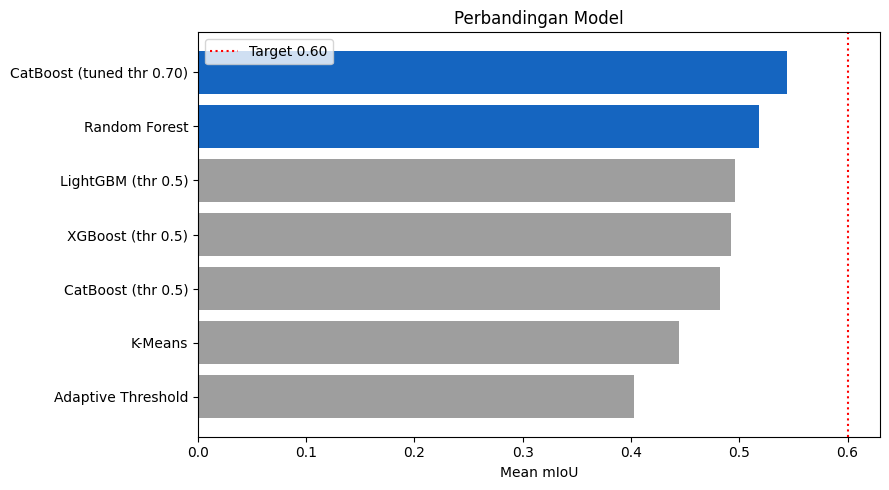

In [18]:
plt.figure(figsize=(9, 5))
colors = ['#2e7d32' if v >= 0.60 else '#1565c0' if v >= RF_MIOU else '#9e9e9e'
          for v in summary['mIoU']]
plt.barh(summary.index[::-1], summary['mIoU'][::-1], color=colors[::-1])
plt.axvline(0.60, color='red', linestyle=':', label='Target 0.60')
plt.xlabel('Mean mIoU'); plt.title('Perbandingan Model'); plt.legend()
plt.tight_layout(); plt.show()


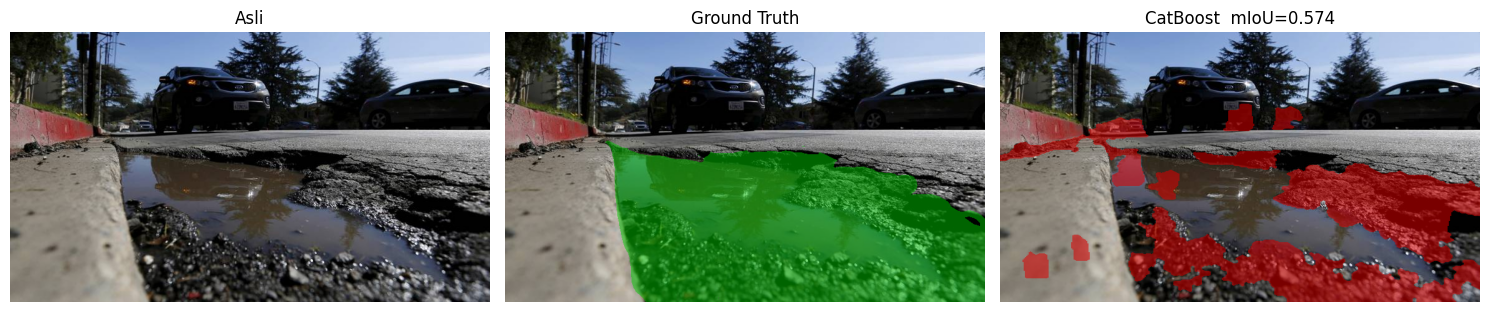

In [19]:
# Demo visual pada satu gambar validasi
demo = val_cache[len(val_cache) // 3]
bgr  = cv2.imread(str(TRAIN_IMG_DIR / f'{demo["name"]}.jpg'))
pred = detect_model(bgr, best_model, threshold=best_thr)
m    = compute_metrics(pred, demo['gt'])

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)); ax[0].set_title('Asli')
gt_ov = make_overlay(bgr, demo['gt'], color_bgr=(0, 200, 0), alpha=0.5)
ax[1].imshow(cv2.cvtColor(gt_ov, cv2.COLOR_BGR2RGB)); ax[1].set_title('Ground Truth')
pr_ov = make_overlay(bgr, pred, color_bgr=(0, 0, 220), alpha=0.55)
ax[2].imshow(cv2.cvtColor(pr_ov, cv2.COLOR_BGR2RGB))
ax[2].set_title(f'{best_name}  mIoU={m["mIoU"]:.3f}')
for a in ax: a.axis('off')
plt.tight_layout(); plt.show()


## 8 - Simpan Model Terbaik untuk App


In [20]:
bundle = {
    'model':         best_model,
    'threshold':     best_thr,
    'name':          best_name,
    'feature_names': FEATURE_NAMES,
}
out_path = MODEL_DIR / 'model_boost_9ch.joblib'
joblib.dump(bundle, out_path)
print(f'Tersimpan: {out_path}')
print(f'Model {best_name}, threshold {best_thr:.2f}, mIoU {best_miou:.4f}')


Tersimpan: /Users/fadh/Documents/BINUS/Semester 4/Project_Pothole_CV/model/model_boost_9ch.joblib
Model CatBoost, threshold 0.70, mIoU 0.5440


In [21]:
# --- Kesimpulan (jujur) ---
print('Ringkasan akhir:')
print(f'  RF baseline           : {RF_MIOU:.4f}')
print(f'  Boosting terbaik (val): {best_miou:.4f}  [{best_name}, thr {best_thr:.2f}]')
if best_miou >= 0.60:
    print('  Status: TARGET mIoU >= 0.60 TERCAPAI.')
else:
    print('  Status: target 0.60 BELUM tercapai, namun mengungguli RF.')
    print('  Catatan: peningkatan lebih lanjut butuh fitur baru / segmentasi lebih')
    print('  presisi, bukan sekadar mengganti classifier.')


Ringkasan akhir:
  RF baseline           : 0.5179
  Boosting terbaik (val): 0.5440  [CatBoost, thr 0.70]
  Status: target 0.60 BELUM tercapai, namun mengungguli RF.
  Catatan: peningkatan lebih lanjut butuh fitur baru / segmentasi lebih
  presisi, bukan sekadar mengganti classifier.
